## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## 2. Load the Dataset

In [2]:
df = pd.read_csv("Wholesale customers data.csv")

# Preview
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 3. Data Preprocessing (Cleaning + Log Transform + Standardization)

In [ ]:
# 1. Drop non-numeric metadata columns if present
df_numeric = df.drop(columns=["Channel", "Region"], errors="ignore")

# 2. Log transform to handle skew in wholesale spending
df_log = np.log1p(df_numeric)

# 3. Standardize the log-transformed data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log)

X_scaled[:5]

array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       [ 0.10011141, -0.62401993, -0.3929769 ,  0.6871443 , -0.49858822,
         0.09341105],
       [ 0.84023948, -0.05239645, -0.07935618,  0.17385884, -0.23191782,
         1.29934689]])

## 4. Determine Optimal Number of Clusters (Elbow Method)

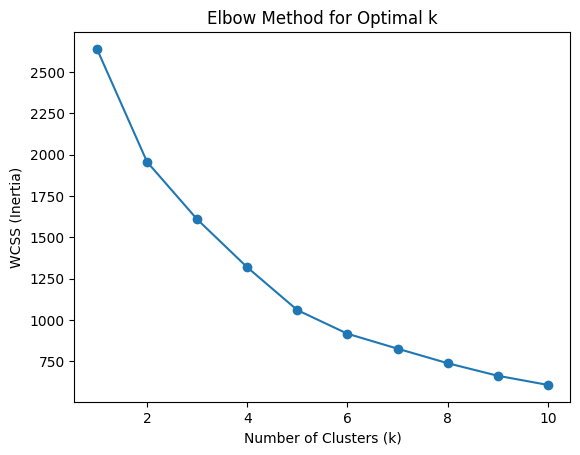

In [5]:
wcss = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure()
plt.plot(k_range, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.show()

### 📌 Choosing k = 3 (Elbow Method Justification)

To determine the optimal number of clusters, I used the **Elbow Method**, which evaluates how the within-cluster sum of squares (WCSS) decreases as k increases.

From the plot, there is a noticeable “elbow” at **k = 3**, where the rate of decrease in WCSS begins to slow down significantly. 

- For **k < 3**, the WCSS decreases sharply, indicating that adding more clusters greatly improves cohesion.
- For **k > 3**, the improvement becomes marginal, meaning additional clusters do not significantly reduce within-cluster variance.

Therefore, **k = 3** provides a good balance between minimizing intra-cluster distance (cohesion) and avoiding unnecessary complexity, making it the most appropriate choice for this dataset.

## 5. Apply K-Means Clustering (k = 3)

In [ ]:
# 3. Cluster with k=3 on standardized log data
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
# attach to original dataframe (kept Channel/Region for later validation)
df["Cluster"] = clusters

# Also keep a working df_clean with the labels for summary
df_clean = df_numeric.copy()
df_clean["Cluster"] = clusters

df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,12669,9656,7561,214,2674,1338,1
1,7057,9810,9568,1762,3293,1776,1
2,6353,8808,7684,2405,3516,7844,1
3,13265,1196,4221,6404,507,1788,1
4,22615,5410,7198,3915,1777,5185,1


## 6. Analyze Cluster Centers

In [7]:
# Convert centers back to original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(centers, columns=df_clean.columns[:-1])
centers_df

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,10440.933333,19386.422222,28656.088889,2190.244444,13327.800000,2374.200000
1,12062.913486,4115.099237,5534.966921,2940.676845,1696.170483,1299.114504
2,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000


## 7. Visualize Clusters Using PCA

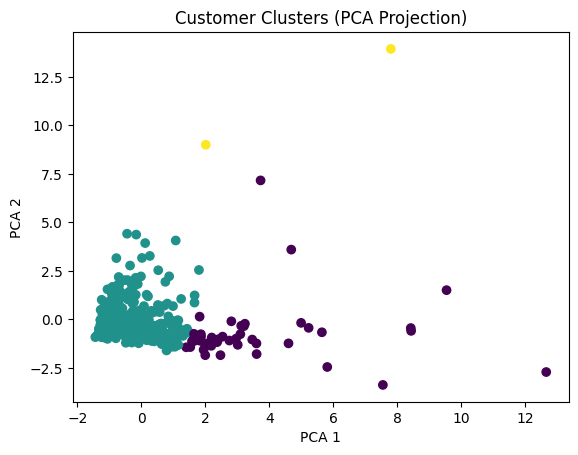

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Clusters (PCA Projection)")
plt.show()

## 8. Cluster Summary (Mean Values per Cluster)

In [9]:
# Mean values per cluster
cluster_summary = df_clean.groupby("Cluster").mean()
cluster_summary

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,10440.933333,19386.422222,28656.088889,2190.244444,13327.800000,2374.200000
1,12062.913486,4115.099237,5534.966921,2940.676845,1696.170483,1299.114504
2,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000


## 9. Cluster Distribution (Number of Points per Cluster)

In [10]:
df_clean["Cluster"].value_counts()

Cluster
1    393
0     45
2      2
Name: count, dtype: int64

## 10. Validation Strategy

- Cross-Reference with `Channel`: After clustering, check if `Cluster 0` (Retailers) aligns with the original `Channel` column (where 2 = Retail). A high overlap indicates the model discovered real business type structure.
- PCA Visualization: Project the 6D (log-scaled) data into 2D using PCA and plot by cluster label. Seeing three separate clouds with minimal overlap confirms `k=3` is appropriate.

```python
# Cross-reference cluster labels vs Channel
print(pd.crosstab(df["Cluster"], df["Channel"], rownames=["Cluster"], colnames=["Channel"]))

# PCA check
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"], cmap='viridis', alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA projection colored by cluster")
plt.show()
```